# Probabilistic segmentation on FLAIR2: flat vs hierarchical latents

Probabilistic segmentation models are meant for images that admit more than
one correct labeling. Instead of a single segmentation they return a
distribution, from which one can draw plausible alternatives. This tutorial
compares three models on [FLAIR2](https://ignf.github.io/FLAIR/) aerial imagery
(French national mapping agency, served through
[GeoBenchV2](https://github.com/microsoft/geobench-v2)):

| Model | Latent structure | What it gives you |
|---|---|---|
| `DeterministicSegmentation` | none | one segmentation, no sample distribution |
| `ProbUNet` | one global latent | diverse plausible segmentations |
| `HierarchicalProbUNet` | one latent per decoder scale | diversity organized by spatial scale |

All three share the same frozen, self-supervised pretrained image encoder
(DINOv3 ConvNeXt-B), so the differences between them come from what is trained
on top of it: the decoder, and for the two probabilistic models the latent
structure. We compare the models in output space: mIoU, sample diversity, and
above all whether the sampled labelings follow the correct distribution.

That last comparison needs a ground-truth distribution, which FLAIR2 does not
provide on its own. FLAIR2 ships one annotation per tile, so the distance
between ground-truth labelings is identically zero and the model that scores
best on the generalized energy distance (GED) is the one with no diversity at
all. Following Kohl et al. (2018) on Cityscapes, we therefore **construct** the
ambiguity with probabilities we choose, which gives an exact distribution to
score every model against.

## Constructing the ambiguity

Kohl et al. (2018) flip five classes to five **newly introduced** classes with
fixed probabilities. We transfer that construction to FLAIR2, turning its 13
classes into 18:

| base class | flips to | probability |
|---|---|---:|
| `deciduous` | `deciduous 2` | 8/17 |
| `brushwood` | `brushwood 2` | 7/17 |
| `herbaceous vegetation` | `herbaceous vegetation 2` | 6/17 |
| `agricultural land` | `agricultural land 2` | 5/17 |
| `impervious surface` | `impervious surface 2` | 4/17 |

Five independent flips give 2^5 = 32 discrete modes, with probabilities from
10.88% (nothing flipped) down to 0.47% (everything flipped). Because we chose
those probabilities, the ground-truth distribution is a mixture of 32 labelings
with known weights, and we can ask whether a model recovers it.

The pairs follow ambiguities that FLAIR's own annotation protocol documents.
`deciduous` versus `coniferous` is unresolvable often enough that FLAIR ships a
dedicated "ligneous" label for it, and `brushwood` is separated from
`deciduous` by a 5 m height threshold that RGB imagery cannot see. GeoBench's
13-class version discards those weak labels, so the construction reinstates a
kind of uncertainty the annotators had already recorded.

Three properties of the construction matter for everything that follows:

- **A flip introduces a new label** rather than mapping onto an existing class,
  so the mode of any labeling can be read off the label map. Had we flipped
  `deciduous` to `coniferous`, a `coniferous` pixel would be ambiguous between
  "really coniferous" and "flipped deciduous", and the exact ground truth
  would be lost.
- **A flip is a whole-tile decision.** When `deciduous` flips, every
  `deciduous` pixel in that tile flips together, which is what makes the modes
  discrete and countable.
- **A flip is independent of the image.** No pixel carries information about
  whether its tile flipped, so the best any model can do is learn how often
  each flip happens. This caps the achievable 18-class mIoU well below 1, as
  measured in the results section.

The training split draws a fresh flip every time a tile is loaded, so a tile
is seen under many of its 32 modes and the model can learn the frequencies.
Validation and test use a fixed per-tile draw, so evaluation is reproducible.

## Setup

The `tacoreader` pin is required. The FLAIR2 archive is a legacy TACO v1
`.tortilla`, which `tacoreader` 2.x rejects with `TacoFormatError`. GeoBenchV2
pins the compatible version itself, but a bare `pip install tacoreader`
alongside it resolves to 2.x and breaks every read.

**Pretrained weights and their licence.** The image encoder is Meta's DINOv3
ConvNeXt-B, loaded through `timm` from the Hugging Face repository
[`timm/convnext_base.dinov3_lvd1689m`](https://huggingface.co/timm/convnext_base.dinov3_lvd1689m)
on first use. These weights are released under the **DINOv3 License**, not
under lightning-uq-box's Apache-2.0 licence. Downloading them means accepting
Meta's terms, so read them on the model page before using the weights in your
own work.

This notebook needs a GPU. It expects FLAIR2 under `FLAIR2_ROOT`; pass
`download=True` to the datamodule to fetch it from Hugging Face instead.

In [1]:
# Copyright (c) 2023 lightning-uq-box. All rights reserved.
# Licensed under the Apache License 2.0.
# %pip install lightning-uq-box
# %pip install GeoBenchV2 "tacoreader==0.5.6" timm

In [2]:
import itertools
import os
import tempfile
from functools import partial

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import segmentation_models_pytorch as smp
import torch
from geobench_v2.datamodules import GeoBenchFLAIR2DataModule
from geobench_v2.datasets import GeoBenchFLAIR2
from lightning import Trainer, seed_everything
from lightning.pytorch.callbacks import Callback, EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from torch import Tensor, nn
from torch.optim.lr_scheduler import LambdaLR
from torchmetrics import JaccardIndex

from lightning_uq_box.eval_utils import (
    generalized_energy_distance,
    hungarian_matched_iou,
    iou_with_empty_convention,
)
from lightning_uq_box.models import HierarchicalProbUNet as HierarchicalModel
from lightning_uq_box.uq_methods import (
    DeterministicSegmentation,
    HierarchicalProbUNet,
    ProbUNet,
)
from lightning_uq_box.viz_utils import plot_training_metrics

seed_everything(0)

DATA_ROOT = os.environ.get("FLAIR2_ROOT", "data/flair2")
IMG_SIZE = 256
CMAP = plt.cm.tab20
device = "cuda" if torch.cuda.is_available() else "cpu"

/path/to/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/path/to/venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


/path/to/venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


2026-09-23 19:51:12,642 - INFO - Asdfghjkl backend not available since the old asdfghjkl dependency is not installed. If you want to use it, run: pip install git+https://git@github.com/wiseodd/asdl@asdfghjkl


[rank: 0] Seed set to 0


### The construction in code

`FLIPS` holds the five pairs. `apply_mode` applies one of the 32 modes to a
label map, `mode_of` reads the mode back, and `mode_probabilities` gives each
mode's analytic probability. The flip runs at the dataset level, inside each
sample's transforms, rather than as a batch augmentation: Lightning's batch
augmentation hook only fires when a trainer is attached, so a batch-level flip
would silently skip every manual dataloader loop in this notebook.

One detail in `mode_of` matters later. If a tile contains no `agricultural
land`, the agricultural flip leaves no trace in it, and that tile's labeling
is consistent with the flip having fired or not. Such positions are reported
as `UNOBSERVABLE` rather than as "unflipped", because counting them as
unflipped would push every measured histogram toward the all-unflipped mode,
which is also the most probable one.

In [3]:
# (base class, introduced variant, flip probability): Kohl et al.'s 8/17 ... 4/17.
FLIPS = (
    (6, 13, 8 / 17),  # deciduous         -> deciduous 2
    (7, 14, 7 / 17),  # brushwood         -> brushwood 2
    (9, 15, 6 / 17),  # herbaceous veg.   -> herbaceous vegetation 2
    (10, 16, 5 / 17),  # agricultural land -> agricultural land 2
    (2, 17, 4 / 17),  # impervious surf.  -> impervious surface 2
)
BASE_CLASSES = GeoBenchFLAIR2.classes
NUM_CLASSES = len(BASE_CLASSES) + len(FLIPS)  # 18
CLASSES = BASE_CLASSES + tuple(f"{BASE_CLASSES[b]} 2" for b, _, _ in FLIPS)
UNOBSERVABLE = -1


def mode_probabilities() -> dict[tuple[int, ...], float]:
    # Analytic probability of each of the 32 modes (5-tuples of 0/1 flips).
    out = {}
    for mode in itertools.product((0, 1), repeat=len(FLIPS)):
        out[mode] = float(
            np.prod([p if bit else 1 - p for bit, (_, _, p) in zip(mode, FLIPS)])
        )
    return out


def apply_mode(mask: Tensor, mode: tuple[int, ...]) -> Tensor:
    # Every comparison reads the original mask, so flips cannot cascade.
    out = mask.clone()
    for bit, (base, variant, _) in zip(mode, FLIPS):
        if bit:
            out[mask == base] = variant
    return out


def mode_of(mask: Tensor) -> tuple[int, ...]:
    # 1 = flipped, 0 = unflipped, UNOBSERVABLE = base class absent from the tile.
    out = []
    for base, variant, _ in FLIPS:
        if (mask == variant).any():
            out.append(1)
        elif (mask == base).any():
            out.append(0)
        else:
            out.append(UNOBSERVABLE)
    return tuple(out)


def collapse(mask: Tensor) -> Tensor:
    # Map every variant back to its base class: the 13-class view of a labeling.
    out = mask.clone()
    for base, variant, _ in FLIPS:
        out[mask == variant] = base
    return out


class AmbiguousLabels(nn.Module):
    # "resample" draws a fresh mode on every load (training); "fixed" derives a
    # reproducible per-tile mode from the sample index (validation and test).
    def __init__(self, mode: str, seed: int = 0) -> None:
        super().__init__()
        self.mode, self.seed = mode, seed

    def forward(self, sample: dict[str, Tensor]) -> dict[str, Tensor]:
        if self.mode == "fixed":
            # A dedicated generator keyed on the index, never the global RNG,
            # which would desynchronize across dataloader workers.
            gen = torch.Generator().manual_seed(
                self.seed * 1_000_003 + int(sample["index"])
            )
            draws = torch.rand(len(FLIPS), generator=gen)
        else:
            draws = torch.rand(len(FLIPS))
        mode = tuple(int(d < p) for d, (_, _, p) in zip(draws, FLIPS))
        sample["mask"] = apply_mode(sample["mask"], mode)
        return sample


class Then(nn.Module):
    # A plain module rather than nn.Sequential: the datamodule rejects falsy
    # transforms, and an empty nn.Sequential is falsy.
    def __init__(self, first: nn.Module, second: nn.Module) -> None:
        super().__init__()
        self.first, self.second = first, second

    def forward(self, sample: dict[str, Tensor]) -> dict[str, Tensor]:
        return self.second(self.first(sample))


class IndexedFLAIR2(GeoBenchFLAIR2):
    # The base __getitem__ applies its transforms internally, before an index
    # could be attached, so the transforms are detached and re-applied here.
    def __init__(self, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        self._sample_transforms, self.transforms = self.transforms, None

    def __getitem__(self, idx: int) -> dict[str, Tensor]:
        sample = super().__getitem__(idx)
        sample["index"] = torch.tensor(idx)
        if self._sample_transforms is not None:
            sample = self._sample_transforms(sample)
        return sample


class AmbiguousFLAIR2DataModule(GeoBenchFLAIR2DataModule):
    def __init__(self, *args, seed: int = 0, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        self.seed = seed
        self.dataset_class = IndexedFLAIR2

    def setup_image_size_transforms(self):
        # The flip runs after the resize in every split.
        train, val, test = super().setup_image_size_transforms()
        return (
            Then(train, AmbiguousLabels("resample", self.seed)),
            Then(val, AmbiguousLabels("fixed", self.seed)),
            Then(test, AmbiguousLabels("fixed", self.seed)),
        )

    def setup(self, stage: str) -> None:
        # super().setup() resets num_classes to 13 on every call.
        super().setup(stage)
        self.num_classes, self.class_names = NUM_CLASSES, CLASSES


assert abs(sum(mode_probabilities().values()) - 1) < 1e-12
print(f"{NUM_CLASSES} classes:", ", ".join(CLASSES))

18 classes: building, previous surface, impervious surface, bare soil, water, coniferous, deciduous, brushwood, vineyard, herbaceous vegetation, agricultural land, plowed land, other, deciduous 2, brushwood 2, herbaceous vegetation 2, agricultural land 2, impervious surface 2


## Data

`band_order` selects RGB from the aerial modality and drops near-infrared and
elevation, so the models see the three channels their pretrained encoder
expects. GeoBenchV2 applies `ZScoreNormalizer` at the dataset level, so no
manual statistics are needed.

`train_augmentations="default"` has to be passed explicitly. The FLAIR2
datamodule defaults this argument to `None`, which maps to `nn.Identity` and
trains without augmentation; the string `"default"` enables the horizontal
and vertical flips.

In [4]:
datamodule = AmbiguousFLAIR2DataModule(
    img_size=IMG_SIZE,
    band_order={"aerial": ["red", "green", "blue"]},
    batch_size=16,
    eval_batch_size=32,
    num_workers=8,
    pin_memory=True,
    train_augmentations="default",
    eval_augmentations="default",
    root=DATA_ROOT,
    download=False,
    seed=0,
)
datamodule.setup("fit")
datamodule.setup("test")
assert datamodule.num_classes == NUM_CLASSES, datamodule.num_classes
print(
    f"train {len(datamodule.train_dataset)} | "
    f"val {len(datamodule.val_dataset)} | test {len(datamodule.test_dataset)}"
)

batch = next(iter(datamodule.train_dataloader()))
for key, value in batch.items():
    print(f"{key:14s} {tuple(value.shape)} {value.dtype}")

Initializing normalizer from class: ZScoreNormalizer
Initializing normalizer from class: ZScoreNormalizer
Initializing normalizer from class: ZScoreNormalizer
train 4049 | val 1022 | test 3022


image_aerial   (16, 3, 256, 256) torch.float32
mask           (16, 256, 256) torch.int64
index          (16,) torch.int64


### Sanity check the batch before training anything

Look for RGB tiles that read as aerial photography, masks whose class indices
land in 0-17, and variant classes (13-17) actually appearing. If none show up,
the flip is not reaching the model and every number downstream is measured
against unflipped labels.

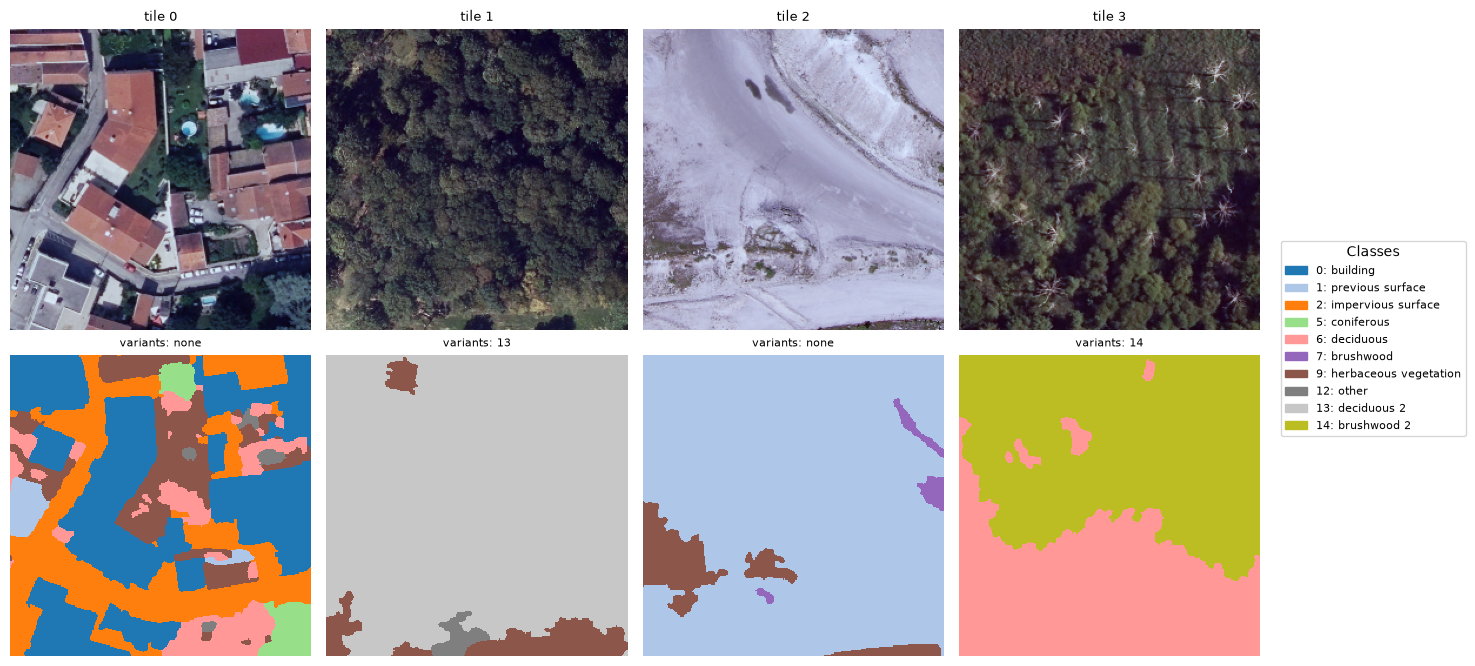

mask range [0, 17] over 18 classes


In [5]:
images, masks = batch["image_aerial"], batch["mask"]
n = min(4, images.shape[0])

fig, axes = plt.subplots(2, n, figsize=(3.2 * n, 6.8))
for i in range(n):
    img = images[i].permute(1, 2, 0).float()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"tile {i}", fontsize=9)
    axes[1, i].imshow(
        masks[i], cmap=CMAP, vmin=0, vmax=NUM_CLASSES - 1, interpolation="nearest"
    )
    variants = sorted(c for c in set(masks[i].flatten().tolist()) if c >= 13)
    axes[1, i].set_title(
        "variants: " + (", ".join(str(v) for v in variants) or "none"), fontsize=8
    )
for ax in axes.ravel():
    ax.axis("off")

handles = [
    mpatches.Patch(color=CMAP(c / (NUM_CLASSES - 1)), label=f"{c}: {CLASSES[c]}")
    for c in sorted(set(masks[:n].flatten().tolist()))
]
fig.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=8,
    title="Classes",
)
plt.tight_layout()
plt.show()
plt.close(fig)

assert masks.min() >= 0 and masks.max() <= NUM_CLASSES - 1
print(f"mask range [{int(masks.min())}, {int(masks.max())}] over {NUM_CLASSES} classes")

## Models

All three models use the same DINOv3 ConvNeXt-B image encoder, and in all
three it is **frozen**: its weights stay at their pretrained values and only
the decoder, the segmentation head and the latent networks train. Two
measurements motivated this. First, in training runs outside this notebook
with the deterministic model on this same task, fine-tuning the ConvNeXt-B
encoder reached 0.3896 and 0.3766 validation mIoU over two seeds, while the
frozen encoder reached 0.3756 at about a third of the training time, so
freezing costs no more than the spread between seeds. Second, those fine-tuned
runs scored best at the lowest learning rate tried (3e-5), which suggests the
pretrained features are worth protecting from the gradients of a randomly
initialized decoder. A frozen shared encoder also makes the comparison
cleaner, since all three models then read identical image features.

`smp` resolves `encoder_weights="imagenet"` for a `tu-` encoder by passing
`pretrained=True` to `timm`, which loads the weights named by the model tag,
here `dinov3_lvd1689m`. The name of the argument is historical and has
nothing to do with ImageNet in this case.

Which module gets frozen differs per model:

- `DeterministicSegmentation` and `ProbUNet` wrap an `smp.Unet`, whose encoder
  is `model.encoder`. The ProbUNet's prior and posterior networks are small
  convolutional encoders trained from scratch, so they stay trainable.
- `HierarchicalProbUNet` has two encoders. The prior encoder sees only the
  image and is frozen like the others. The posterior encoder sees the image
  **and** the one-hot ground truth (3 + 18 channels), so its first layer
  cannot be the pretrained one: `timm` adapts the pretrained stem to 21
  channels, and the posterior encoder trains. It gets its own, smaller
  learning rate, since a pretrained ConvNeXt fine-tuned at the decoder's
  learning rate degraded in the runs mentioned above.

`input_key` and `target_key` are **class** attributes on `BaseModule`
(defaulting to `"input"`/`"target"`), not constructor arguments. FLAIR2 emits
`image_aerial`/`mask`, so they are overridden on each instance, and they must
be re-applied after any checkpoint load.

In [6]:
ENCODER = "tu-convnext_base.dinov3_lvd1689m"
LR = 1e-3  # decoder, head and latent networks
POSTERIOR_ENCODER_LR = 3e-5  # the hierarchical model's trainable posterior encoder
WEIGHT_DECAY = 0.01
WARMUP_EPOCHS = 2
# (max_epochs, early-stopping patience; 0 turns early stopping off), per model.
# Each budget is set so that the best checkpoint falls well inside it; see
# the Training section.
BUDGET = {
    "Deterministic": (50, 10),
    "ProbUNet": (100, 0),
    "HierarchicalProbUNet": (100, 10),
}


def warmup_cosine(epoch: int, max_epochs: int) -> float:
    # Linear warmup, then cosine decay to 0. In epochs, not steps: the
    # library returns the scheduler without an "interval" key, so Lightning
    # steps it once per epoch.
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    t = (epoch - WARMUP_EPOCHS) / max(1, max_epochs - WARMUP_EPOCHS)
    return 0.5 * (1 + np.cos(np.pi * min(1.0, t)))


def lr_scheduler(name: str):
    # The cosine spans each model's own epoch budget.
    return partial(
        LambdaLR, lr_lambda=partial(warmup_cosine, max_epochs=BUDGET[name][0])
    )


optimizer = partial(torch.optim.AdamW, lr=LR, weight_decay=WEIGHT_DECAY)


def with_slow_group(optimizer, slow: nn.Module, slow_lr: float):
    # The library builds its optimizer as `self.optimizer(self.parameters())`,
    # so per-module learning rates have to be formed inside that callable.
    # LambdaLR then scales each group's own learning rate by the same factor.
    slow_ids = {id(p) for p in slow.parameters()}

    def build(params):
        params = [p for p in params if p.requires_grad]
        return optimizer(
            [
                {"params": [p for p in params if id(p) not in slow_ids]},
                {"params": [p for p in params if id(p) in slow_ids], "lr": slow_lr},
            ]
        )

    return build


def make_unet() -> nn.Module:
    return smp.Unet(
        encoder_name=ENCODER,
        encoder_weights="imagenet",
        in_channels=3,
        classes=NUM_CLASSES,
    )


def attach_keys(method):
    method.input_key = "image_aerial"
    method.target_key = "mask"
    return method


def freeze(module: nn.Module) -> nn.Module:
    for p in module.parameters():
        p.requires_grad_(False)
    return module.eval()


deterministic = attach_keys(
    DeterministicSegmentation(
        model=make_unet(),
        loss_fn=nn.CrossEntropyLoss(),
        task="multiclass",
        optimizer=optimizer,
        lr_scheduler=lr_scheduler("Deterministic"),
    )
)
prob_unet = attach_keys(
    ProbUNet(
        model=make_unet(),
        latent_dim=6,
        beta=1.0,
        num_samples=8,
        task="multiclass",
        optimizer=optimizer,
        lr_scheduler=lr_scheduler("ProbUNet"),
    )
)
hier_backbone = HierarchicalModel(
    encoder_name=ENCODER,
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
    latent_dims=(1, 1, 1, 1),
)
hierarchical = attach_keys(
    HierarchicalProbUNet(
        model=hier_backbone,
        num_classes=NUM_CLASSES,
        loss_type="elbo",
        beta=1.0,
        num_samples=8,
        task="multiclass",
        optimizer=with_slow_group(
            optimizer, hier_backbone.posterior_encoder, POSTERIOR_ENCODER_LR
        ),
        lr_scheduler=lr_scheduler("HierarchicalProbUNet"),
    )
)

MODELS = {
    "Deterministic": deterministic,
    "ProbUNet": prob_unet,
    "HierarchicalProbUNet": hierarchical,
}
FROZEN = {
    "Deterministic": freeze(deterministic.model.encoder),
    "ProbUNet": freeze(prob_unet.model.encoder),
    "HierarchicalProbUNet": freeze(hier_backbone.prior_encoder),
}
for name, method in MODELS.items():
    total = sum(p.numel() for p in method.parameters())
    trainable = sum(p.numel() for p in method.parameters() if p.requires_grad)
    print(
        f"{name:22s} {total / 1e6:6.1f}M parameters, {trainable / 1e6:6.1f}M trainable"
    )

2026-09-23 19:51:19,696 - INFO - Loading pretrained weights from Hugging Face hub (timm/convnext_base.dinov3_lvd1689m)


2026-09-23 19:51:19,722 - INFO - [timm/convnext_base.dinov3_lvd1689m] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


2026-09-23 19:51:21,756 - INFO - Loading pretrained weights from Hugging Face hub (timm/convnext_base.dinov3_lvd1689m)


2026-09-23 19:51:21,759 - INFO - [timm/convnext_base.dinov3_lvd1689m] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


2026-09-23 19:51:23,314 - INFO - Loading pretrained weights from Hugging Face hub (timm/convnext_base.dinov3_lvd1689m)


2026-09-23 19:51:23,316 - INFO - [timm/convnext_base.dinov3_lvd1689m] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


2026-09-23 19:51:24,776 - INFO - Loading pretrained weights from Hugging Face hub (timm/convnext_base.dinov3_lvd1689m)


2026-09-23 19:51:24,779 - INFO - [timm/convnext_base.dinov3_lvd1689m] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


2026-09-23 19:51:25,105 - INFO - Converted input conv stem.0 pretrained weights from 3 to 21 channel(s)


Deterministic            92.7M parameters,    5.1M trainable
ProbUNet                 95.4M parameters,    7.8M trainable
HierarchicalProbUNet    202.9M parameters,  115.4M trainable


### The two objectives, and what `beta` means in each

Both probabilistic models trade a reconstruction term against a KL term with
weight `beta`, and both use `beta=1.0` here, but the two numbers are not the
same quantity. Flat `ProbUNet` weights a **per-image pixel sum** of the
cross-entropy, the scale Kohl et al. use, so `beta=1.0` is the paper's value.
`HierarchicalProbUNet` with `loss_type="elbo"` computes
`rec["sum"] + beta * kl_sum`, where `rec["sum"]` sums the cross-entropy over
only the top-k hardest ("mined") pixels, so its reconstruction term lives on a
different scale. Therefore, never compare the two models' loss curves with
each other; only the output-space metrics below are comparable.

`HierarchicalProbUNet` defaults to GECO, a constrained objective. On this
dataset GECO switched off the coarse latent scales in every configuration
tried (2 of 4 scales still active late in training), whereas the ELBO kept
more of them active, which is why the ELBO is used here. `beta=1.0` was
selected among 1e-5, 0.3 and 1.0 by the prior-versus-posterior gate
introduced in the next section.

## Training

The optimizer is the same for all three models: AdamW with weight decay 0.01,
a two-epoch linear warmup, then cosine decay to zero over the model's epoch
budget. The budgets differ, because the models converge at different speeds:

| model | max epochs | early stopping | best epoch in the shipped run |
|---|---|---|---|
| Deterministic | 50 | patience 10 | 24 |
| ProbUNet | 100 | off | 60 |
| HierarchicalProbUNet | 100 | patience 10 | 70 |

A budget is large enough when the best checkpoint lands well before it ends.
A flat validation curve at the end of a cosine schedule does not show this:
the learning rate is close to zero there, so the curve flattens whether or not
the model has converged. With a 50-epoch budget both ProbUNets had their best
epoch at or near the end. At 100 epochs the hierarchical model gained 13% in
validation loss. Flat ProbUNet gained within seed noise, and its validation loss
rises again after about epoch 60.

Early stopping is off for flat ProbUNet because, with a 100-epoch cosine, the
learning rate is still high around epoch 40 to 50. Its noisy validation loss
then ends the run after 10 epochs without improvement, before the low learning
rate phase in which it improves most. The checkpoint is still the one with the
lowest validation loss, so turning early stopping off only costs compute.

The monitored metric differs between the models for a reason specific to the
probabilistic ones. The deterministic model selects its checkpoint on
validation mIoU. The two ProbUNets log a `valJaccard` too, but their
validation step scores **posterior** reconstructions, which have seen the
ground-truth mask. That number says nothing about the prior samples used at
test time, so both ProbUNets select on `val_loss` instead.

`KeepEncoderEval` holds each frozen encoder in eval mode. Lightning calls
`model.train()` after every validation loop, which would put BatchNorm layers
back into updating their running statistics, a frozen encoder that still
drifts. ConvNeXt normalizes with LayerNorm, so here this is a safeguard for
readers who swap in a BatchNorm encoder such as a ResNet.

Precision is `32-true` rather than `16-mixed` because the hierarchical model's
per-scale KL terms reach the order of 1e4 early in training, close enough to
fp16's 65504 ceiling that overflow is a real risk.

In [7]:
class KeepEncoderEval(Callback):
    def __init__(self, encoder: nn.Module) -> None:
        self.encoder = encoder

    def on_train_batch_start(self, trainer, pl_module, batch, batch_idx) -> None:
        self.encoder.eval()


MONITOR = {
    "Deterministic": ("valJaccard", "max"),
    "ProbUNet": ("val_loss", "min"),
    "HierarchicalProbUNet": ("val_loss", "min"),
}


def make_trainer(name: str) -> Trainer:
    monitor, mode = MONITOR[name]
    max_epochs, patience = BUDGET[name]
    callbacks = [
        ModelCheckpoint(
            dirpath=os.path.join(LOG_ROOT, name),
            filename="best",
            monitor=monitor,
            mode=mode,
        ),
        KeepEncoderEval(FROZEN[name]),
    ]
    if patience:
        callbacks.append(EarlyStopping(monitor=monitor, mode=mode, patience=patience))
    return Trainer(
        max_epochs=max_epochs,
        accelerator="gpu",
        devices=1,
        precision="32-true",
        gradient_clip_val=1.0,
        check_val_every_n_epoch=1,
        default_root_dir=os.path.join(LOG_ROOT, name),
        logger=CSVLogger(os.path.join(LOG_ROOT, name)),
        callbacks=callbacks,
        enable_model_summary=False,
    )


# Training all three models takes about four hours on one GPU, most of it the
# hierarchical model. FLAIR2_TRAINED can point at a directory holding
# <model>/best.ckpt (+ summary.json) from the same recipe, to skip training.
TRAINED = os.environ.get("FLAIR2_TRAINED", "")
LOG_ROOT = TRAINED if TRAINED else tempfile.mkdtemp()

for name, method in MODELS.items():
    frozen_before = {k: v.clone() for k, v in FROZEN[name].state_dict().items()}
    if TRAINED:
        ckpt = os.path.join(TRAINED, name, "best.ckpt")
    else:
        print(f"\n=== training {name} ===")
        trainer = make_trainer(name)
        trainer.fit(method, datamodule=datamodule)
        ckpt = trainer.checkpoint_callback.best_model_path
    state = torch.load(ckpt, map_location="cpu", weights_only=False)
    method.load_state_dict(state["state_dict"], strict=True)
    attach_keys(method)
    # The frozen encoder must still hold exactly the pretrained weights.
    assert all(
        torch.equal(v, frozen_before[k]) for k, v in FROZEN[name].state_dict().items()
    ), f"{name}: frozen encoder changed"
    print(f"loaded {name} from {os.path.basename(ckpt)}; frozen encoder unchanged")

loaded Deterministic from best.ckpt; frozen encoder unchanged


loaded ProbUNet from best.ckpt; frozen encoder unchanged


loaded HierarchicalProbUNet from best.ckpt; frozen encoder unchanged


### Convergence gates

Before trusting any figure below, check that training worked. The loss curves
come first; for the hierarchical model the per-scale KL terms matter most,
because **a scale whose KL sits at about 0 is a collapsed latent**. That level
of the hierarchy is then unused, and its row in the per-scale intervention
grid further down will look identical to the baseline because the scale was
never trained, not because it controls nothing. Read the late part of each KL
curve rather than only the final value, since collapse can set in well after
the early transient in which all KL terms are large and falling.

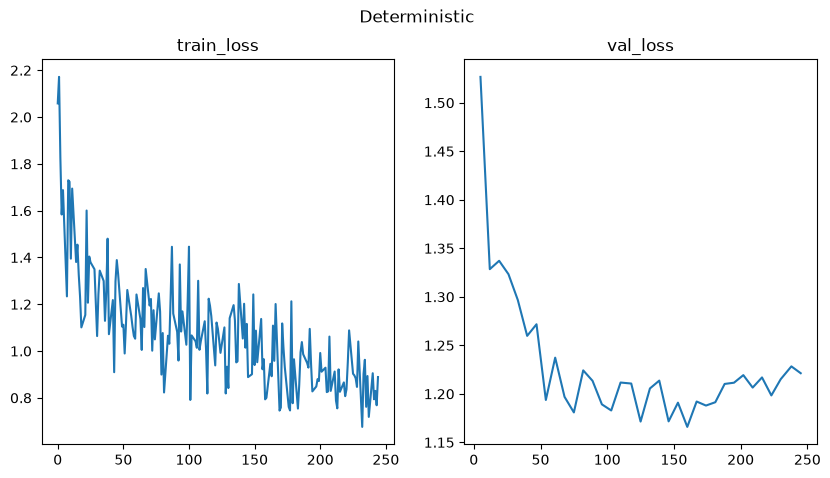

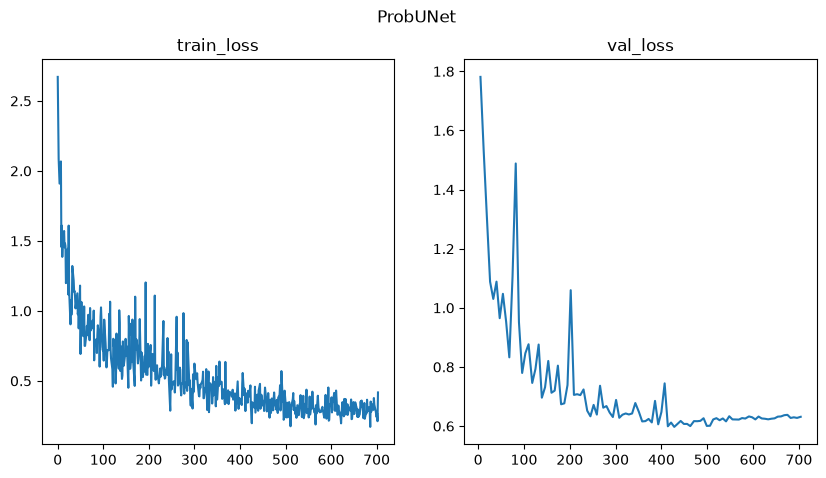

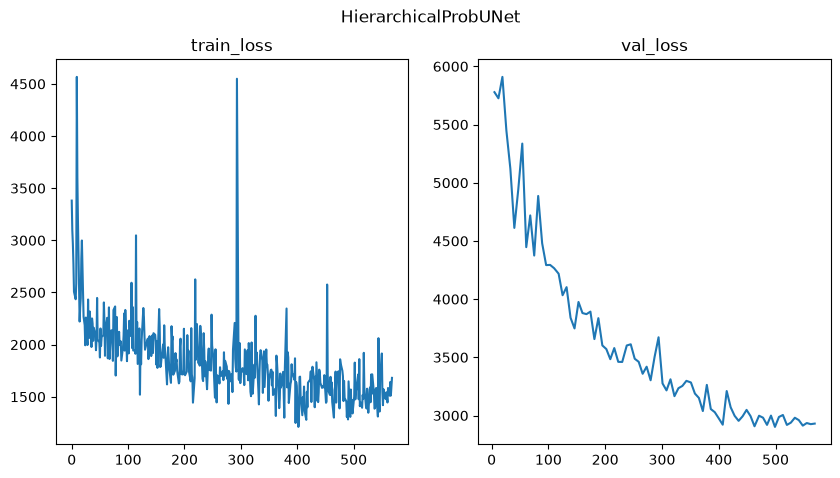

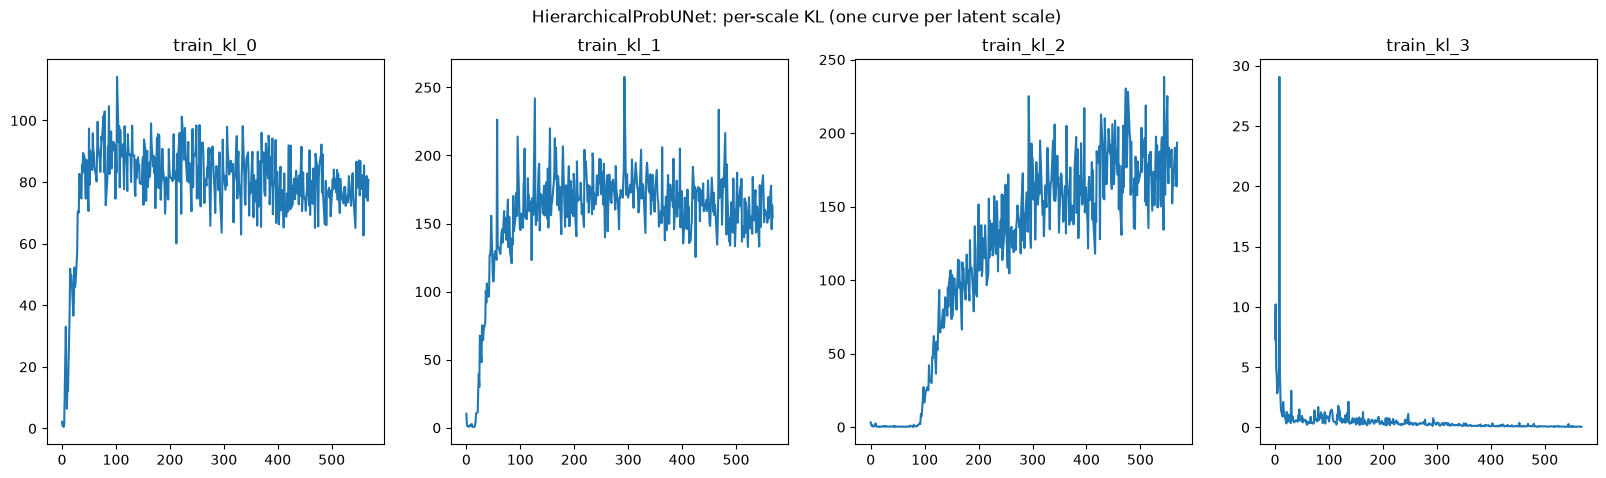

In [8]:
for name in MODELS:
    log_dir = os.path.join(LOG_ROOT, name, "lightning_logs")
    fig = plot_training_metrics(log_dir, ["train_loss", "val_loss"])
    fig.suptitle(name)
    plt.show()
    plt.close(fig)

fig = plot_training_metrics(
    os.path.join(LOG_ROOT, "HierarchicalProbUNet", "lightning_logs"),
    ["train_kl_0", "train_kl_1", "train_kl_2", "train_kl_3"],
)
fig.suptitle("HierarchicalProbUNet: per-scale KL (one curve per latent scale)")
plt.show()
plt.close(fig)

**Per-scale KL is necessary but not sufficient.** A non-zero KL only says the
posterior differs from the prior, not that the prior learned anything useful.
The gate that checks the prior compares two decodings of the same validation
tiles: from the **posterior mean**, which has seen the ground-truth mask, and
from the **prior mean**, which has not and is what sampling at test time
starts from. We require

`posterior Jaccard - prior Jaccard < 0.25`

A larger gap means the model reconstructs from information it will not have
at inference, and is not ready to sample from.

The two models expose this differently. `HierarchicalProbUNet` has
`sample(x, mean=True)` and `reconstruct(x, one_hot_mask, mean=True)`. Flat
`ProbUNet` is stateful: the latent spaces and U-Net features are stored on the
module, the way `compute_loss` sets them during training, and
`reconstruct(use_posterior_mean=True)` then decodes the posterior mean.

In [9]:
@torch.no_grad()
def prior_posterior_jaccard(name: str, method, max_batches: int = 0) -> dict:
    method.eval().to(device)
    prior_scores, post_scores = [], []
    for b, batch in enumerate(datamodule.val_dataloader()):
        if max_batches and b >= max_batches:
            break
        x = batch["image_aerial"].to(device)
        y = batch["mask"].to(device).long()
        if name == "ProbUNet":
            method.prior_latent_space = method.prior.forward(x)
            method.unet_features = method.extract_features(x)
            prior_logits = method.fcomb.forward(
                method.unet_features, method.prior_latent_space.mean
            )
            method.posterior_latent_space = method.posterior.forward(x, y.unsqueeze(1))
            post_logits = method.reconstruct(use_posterior_mean=True)
        else:
            prior_logits = method.sample(x, mean=True)
            one_hot = nn.functional.one_hot(y, NUM_CLASSES).permute(0, 3, 1, 2).float()
            post_logits, _, _ = method.reconstruct(x, one_hot, mean=True)
        for logits, scores in (
            (prior_logits, prior_scores),
            (post_logits, post_scores),
        ):
            scores.append(
                float(
                    iou_with_empty_convention(
                        logits.argmax(1).long(), y, NUM_CLASSES, ignore_background=False
                    ).mean()
                )
            )
    prior, post = float(np.mean(prior_scores)), float(np.mean(post_scores))
    return {
        "prior Jaccard": prior,
        "posterior Jaccard": post,
        "gap": post - prior,
        "passes (< 0.25)": post - prior < 0.25,
    }


gate = pd.DataFrame(
    {
        name: prior_posterior_jaccard(name, MODELS[name])
        for name in ("ProbUNet", "HierarchicalProbUNet")
    }
).T
gate

,prior Jaccard,posterior Jaccard,gap,passes (< 0.25)
ProbUNet,0.573236,0.78819,0.214953,True
HierarchicalProbUNet,0.659757,0.852388,0.192631,True


## Test accuracy, and the ceiling the construction imposes

Test mIoU is scored the way `trainer.test` scores it, with `torchmetrics`
`JaccardIndex` averaged over all 18 classes. For the ProbUNets the prediction
is the argmax of the softmax averaged over `num_samples` prior draws.

Before reading those numbers, it helps to know how high they can go. A flip is
independent of the image, so no model can tell from the pixels whether a tile
flipped. The best a model can do on the 18-class metric is to predict the
more probable member of each pair, which for every pair here is the unflipped
base class. We score that strategy directly, by using the unflipped ground
truth as a "prediction": it is the ceiling for any model, and it sits far
below 1. We also report each model's **collapsed** mIoU, which maps every
variant back to its base class in both prediction and target and so measures
segmentation quality on the original 13 classes without the unobservable flip
decision.

In [10]:
@torch.no_grad()
def test_scores(method) -> tuple[float, float]:
    full = JaccardIndex(task="multiclass", num_classes=NUM_CLASSES).to(device)
    base = JaccardIndex(task="multiclass", num_classes=len(BASE_CLASSES)).to(device)
    method.eval().to(device)
    for batch in datamodule.test_dataloader():
        x = batch["image_aerial"].to(device)
        y = batch["mask"].to(device).long()
        pred = method.predict_step(x)["pred"].argmax(1)
        full.update(pred, y)
        base.update(collapse(pred), collapse(y))
    return float(full.compute()), float(base.compute())


ceiling = JaccardIndex(task="multiclass", num_classes=NUM_CLASSES).to(device)
for batch in datamodule.test_dataloader():
    y = batch["mask"].to(device).long()
    ceiling.update(collapse(y), y)  # always predict the unflipped base class
ceiling = float(ceiling.compute())

accuracy = {}
for name, method in MODELS.items():
    miou, collapsed = test_scores(method)
    accuracy[name] = {
        "test mIoU (18 classes)": miou,
        "fraction of ceiling": miou / ceiling,
        "collapsed mIoU (13 classes)": collapsed,
    }
print(f"ceiling for any model on the 18-class metric: {ceiling:.4f}")
pd.DataFrame(accuracy).T

ceiling for any model on the 18-class metric: 0.6235


,test mIoU (18 classes),fraction of ceiling,collapsed mIoU (13 classes)
Deterministic,0.335636,0.538273,0.515826
ProbUNet,0.294400,0.472141,0.443264
HierarchicalProbUNet,0.307981,0.493922,0.465796


## Predictions

`predict_step` returns `logits` shaped `[B, C, H, W, num_samples]`, with the
samples on the **last** axis. The `eval_utils` metrics expect integer label
maps shaped `[B, N, H, W]`, with the samples on **axis 1**, and raise on float
input. The transpose in `hard_samples` is therefore mandatory; getting it
wrong yields meaningless numbers rather than an error.

In [11]:
eval_batch = next(iter(datamodule.test_dataloader()))
images = eval_batch["image_aerial"].to(device)
targets = eval_batch["mask"].to(device).long()

predictions = {}
for name, method in MODELS.items():
    method.eval().to(device)
    with torch.no_grad():
        predictions[name] = method.predict_step(images)
    print(name, {k: tuple(v.shape) for k, v in predictions[name].items()})


def hard_samples(preds: dict[str, Tensor]) -> Tensor:
    # predict_step logits [B, C, H, W, N] -> integer label maps [B, N, H, W].
    return preds["logits"].argmax(1).permute(0, 3, 1, 2).long()

Deterministic {'pred': (32, 18, 256, 256), 'pred_uct': (32, 256, 256), 'logits': (32, 18, 256, 256)}


ProbUNet {'pred': (32, 18, 256, 256), 'pred_uct': (32, 256, 256), 'logits': (32, 18, 256, 256, 8)}


HierarchicalProbUNet {'pred': (32, 18, 256, 256), 'pred_uct': (32, 256, 256), 'logits': (32, 18, 256, 256, 8)}


### Qualitative comparison

One row per model: input, ground truth, mean prediction and predictive
entropy. The deterministic model has no sample distribution, so its entropy
panel is marked N/A rather than filled with a softmax entropy that means
something different.

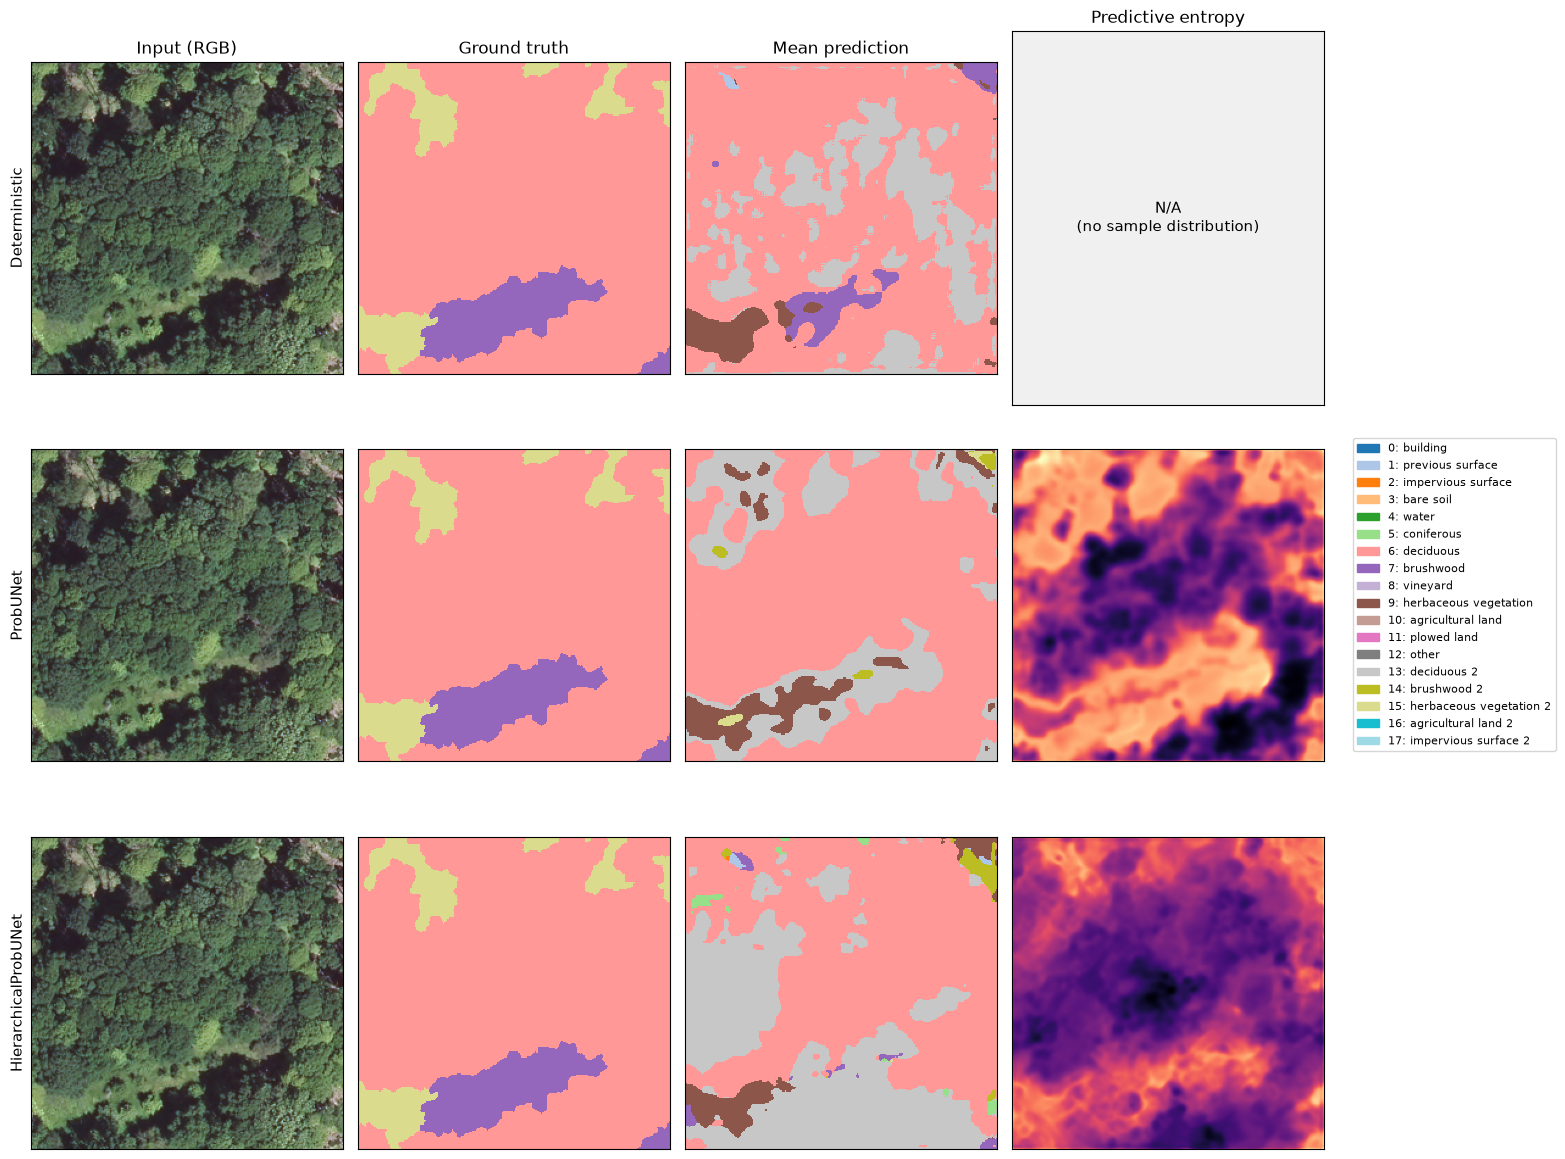

In [12]:
idx = 0
legend = [
    mpatches.Patch(color=CMAP(i / (NUM_CLASSES - 1)), label=f"{i}: {CLASSES[i]}")
    for i in range(NUM_CLASSES)
]
fig, axes = plt.subplots(len(MODELS), 4, figsize=(16, 4 * len(MODELS)))
for row, (name, preds) in enumerate(predictions.items()):
    rgb = images[idx].cpu().movedim(0, -1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    axes[row, 0].imshow(rgb.numpy())
    axes[row, 0].set_ylabel(name, fontsize=11)
    axes[row, 1].imshow(
        targets[idx].cpu(),
        cmap=CMAP,
        vmin=0,
        vmax=NUM_CLASSES - 1,
        interpolation="none",
    )
    axes[row, 2].imshow(
        preds["pred"].argmax(1)[idx].cpu(),
        cmap=CMAP,
        vmin=0,
        vmax=NUM_CLASSES - 1,
        interpolation="none",
    )
    if name == "Deterministic":
        axes[row, 3].text(
            0.5,
            0.5,
            "N/A\n(no sample distribution)",
            ha="center",
            va="center",
            fontsize=11,
        )
        axes[row, 3].set_facecolor("#f0f0f0")
    else:
        axes[row, 3].imshow(preds["pred_uct"][idx].cpu().squeeze(), cmap="magma")
    if row == 0:
        for col, title in enumerate(
            ["Input (RGB)", "Ground truth", "Mean prediction", "Predictive entropy"]
        ):
            axes[row, col].set_title(title)
for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout(rect=(0, 0, 0.84, 1))
fig.legend(handles=legend, loc="center left", bbox_to_anchor=(0.845, 0.5), fontsize=8)
plt.show()
plt.close(fig)

### Sample diversity

Five independent prior draws per probabilistic model for the same tile. Under
the construction, a correct draw changes whole classes at once, for example
every `deciduous` pixel becoming `deciduous 2`, rather than scattering
isolated pixels.

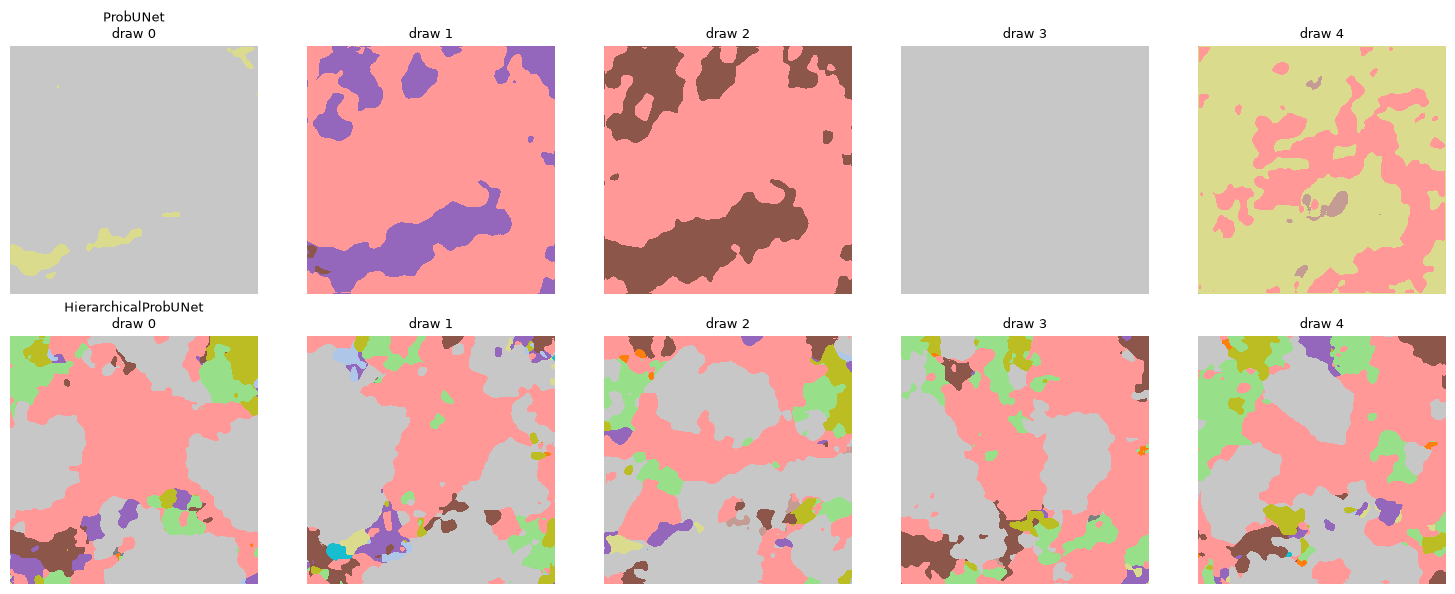

In [13]:
n_draws = 5
prob_models = {k: v for k, v in MODELS.items() if k != "Deterministic"}
fig, axes = plt.subplots(
    len(prob_models), n_draws, figsize=(3 * n_draws, 3 * len(prob_models))
)
for row, name in enumerate(prob_models):
    samples = hard_samples(predictions[name])
    for col in range(n_draws):
        axes[row, col].imshow(
            samples[idx, col].cpu(),
            cmap=CMAP,
            vmin=0,
            vmax=NUM_CLASSES - 1,
            interpolation="none",
        )
        axes[row, col].set_title(
            f"{name}\ndraw {col}" if col == 0 else f"draw {col}", fontsize=9
        )
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()
plt.close(fig)

### Collapse cross-check

Pairwise disagreement is the fraction of pixels on which two independent
prior draws differ, averaged over all pairs of draws in the batch. A value
near zero means the latents have collapsed and the model is effectively
deterministic, which a diversity figure can hide.

In [14]:
for name in prob_models:
    samples = hard_samples(predictions[name])
    n = samples.shape[1]
    pairs = [
        (samples[:, i] != samples[:, j]).float().mean().item()
        for i in range(n)
        for j in range(i + 1, n)
    ]
    print(
        f"{name:22s} mean pairwise disagreement: {np.mean(pairs):.4f}"
        f"  (min {min(pairs):.4f}, max {max(pairs):.4f}, {len(pairs)} pairs)"
    )

ProbUNet               mean pairwise disagreement: 0.6801  (min 0.5902, max 0.7529, 28 pairs)
HierarchicalProbUNet   mean pairwise disagreement: 0.6248  (min 0.5946, max 0.6531, 28 pairs)


### Per-scale latent intervention

This is what distinguishes the hierarchical model. Every latent is held at its
conditional prior mean except one, which is resampled four times, so each row
shows what a single spatial scale controls. Coarse scales (top) act on deeper,
lower-resolution decoder stages.

The hierarchy is autoregressive, so intervening at a coarse scale also shifts
the conditional means of every finer scale below it. The rows are therefore
not independent, and visible variation alone does not establish that the
scales are disentangled. Read this figure next to the per-scale KL curves: a
scale whose KL sat at about 0 shows no variation here because it collapsed.

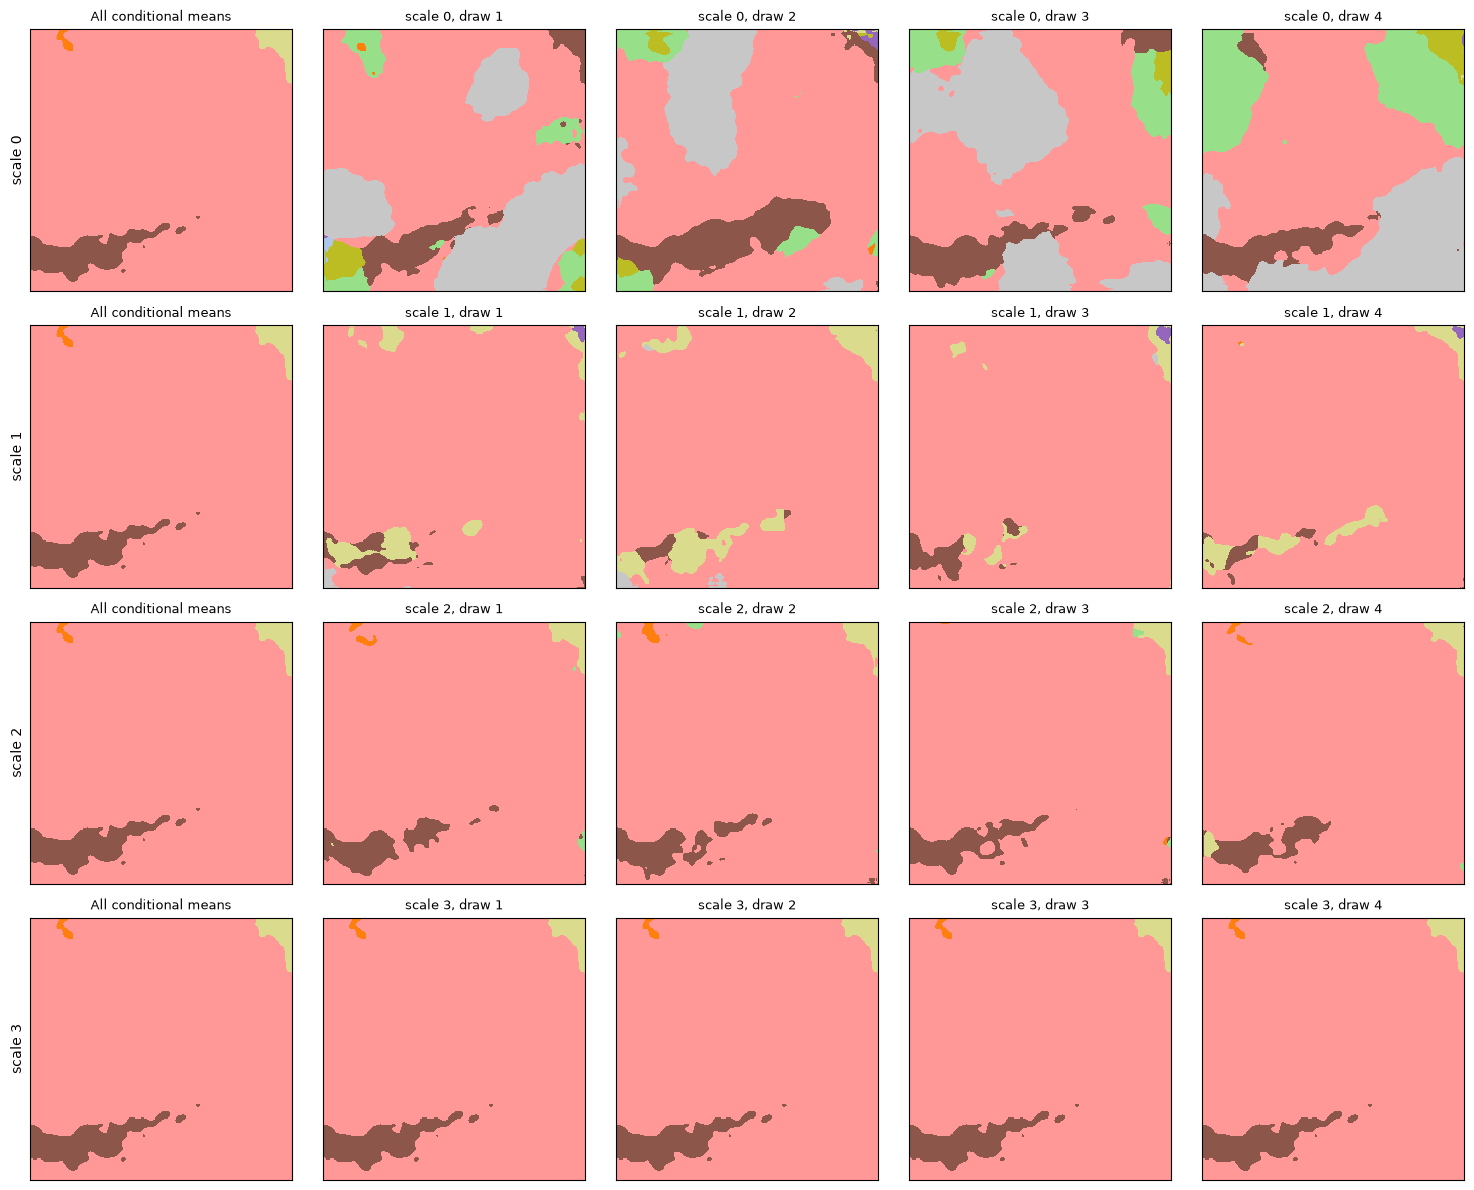

In [15]:
scales = len(hier_backbone.latent_dims)
single = images[idx : idx + 1]
fig, axes = plt.subplots(scales, 5, figsize=(15, 3 * scales), squeeze=False)
with torch.no_grad():
    baseline = hier_backbone.sample(single, mean=True).argmax(1)[0].cpu()
    for scale in range(scales):
        flags = [True] * scales
        flags[scale] = False  # resample only this scale
        axes[scale, 0].imshow(
            baseline, cmap=CMAP, vmin=0, vmax=NUM_CLASSES - 1, interpolation="none"
        )
        axes[scale, 0].set_title("All conditional means", fontsize=9)
        axes[scale, 0].set_ylabel(f"scale {scale}", fontsize=10)
        for col in range(1, 5):
            draw = hier_backbone.sample(single, mean=flags).argmax(1)[0].cpu()
            axes[scale, col].imshow(
                draw, cmap=CMAP, vmin=0, vmax=NUM_CLASSES - 1, interpolation="none"
            )
            axes[scale, col].set_title(f"scale {scale}, draw {col}", fontsize=9)
for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()
plt.close(fig)

## Metrics on one batch

Every call below passes `ignore_background=False`. The default is `True`,
which drops class index 0, and on FLAIR2 **class 0 is `building`**, a real
land-cover class rather than a background label. Leaving the default in place
would silently exclude buildings from every IoU, GED and Hungarian number.

**GED against a known distribution.** With a single annotator, the grader
term `d_yy` is identically 0 and GED squared degenerates to `2 * d_sy - d_ss`,
a quantity that rewards zero diversity. The construction replaces the single
reference with the exact 32-mode mixture: the graders for a tile are its 32
analytic modes, so `d_yy` is a real quantity. Always read `d_ss` (the
diversity among a model's own samples) next to GED, because GED also improves
when samples merely become more diverse.

In [16]:
rows = {}
for name, preds in predictions.items():
    row = {
        "mIoU": float(
            iou_with_empty_convention(
                preds["pred"].argmax(1).long(),
                targets,
                NUM_CLASSES,
                ignore_background=False,
            ).mean()
        ),
        "mean entropy": float(preds["pred_uct"].mean()),
    }
    if name in prob_models:
        samples = hard_samples(preds)
        graders = torch.stack(
            [apply_mode(targets, mode) for mode in mode_probabilities()], dim=1
        )
        ged = generalized_energy_distance(
            samples, graders, NUM_CLASSES, ignore_background=False
        )
        hung = hungarian_matched_iou(
            samples, graders, NUM_CLASSES, ignore_background=False
        )
        row.update(
            {
                "GED2": float(ged["ged"].mean()),
                "d_ss (diversity)": float(ged["d_ss"].mean()),
                "d_yy": float(ged["d_yy"].mean()),
                "Hungarian IoU": float(hung.mean()),
            }
        )
    rows[name] = row
pd.DataFrame(rows).T

,mIoU,mean entropy,GED2,d_ss (diversity),d_yy,Hungarian IoU
Deterministic,0.642347,1.191630,NaN,NaN,NaN,NaN
ProbUNet,0.582078,1.523630,0.327405,0.384483,0.119792,0.640361
HierarchicalProbUNet,0.484761,1.334308,0.620487,0.623981,0.119792,0.325256


### Uncertainty and accuracy

Pixels are binned by predictive-entropy quantile and accuracy is measured per
bin. The bins use quantile edges rather than uniform ones, because predictive
entropy is heavily skewed and uniform bins would leave most of them empty. An
informative uncertainty estimate gives a decreasing curve: the pixels the
model flags as uncertain are the ones it gets wrong. This plot is a statement
about how the model ranks pixels, which is a different question from whether
its samples follow the right distribution; the next section measures the
latter.

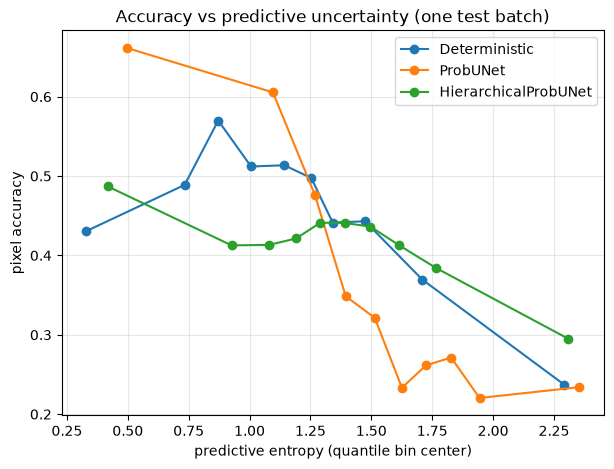

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, preds in predictions.items():
    entropy = preds["pred_uct"].flatten().float()
    correct = (preds["pred"].argmax(1) == targets).flatten().float()
    edges = torch.quantile(entropy, torch.linspace(0, 1, 11).to(entropy.device))
    centers, accuracies = [], []
    for lo, hi in itertools.pairwise(edges):
        mask = (entropy >= lo) & (entropy < hi)
        if mask.sum() > 0:
            centers.append(float((lo + hi) / 2))
            accuracies.append(float(correct[mask].mean()))
    ax.plot(centers, accuracies, marker="o", label=name)
ax.set_xlabel("predictive entropy (quantile bin center)")
ax.set_ylabel("pixel accuracy")
ax.set_title("Accuracy vs predictive uncertainty (one test batch)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()
plt.close(fig)

## Did the models recover the distribution?

This is the measurement the construction exists to enable. For every test
tile we draw 16 labelings from each model, read off which mode each draw is
in, and compare against the analytic distribution the data was built with.
Two summaries come out:

- **Per-flip marginals**: how often each of the five flips fires in the
  model's draws, against its true probability (8/17 ... 4/17). Only positions
  observable in the ground-truth tile count, and a draw that omits a pair's
  classes entirely is not counted as "unflipped", since that is a
  segmentation error rather than evidence about the flip rate.
- **Joint histogram over the 32 modes**, on tiles where all five flips are
  observable, summarized by the total variation distance (TVD) to the
  analytic distribution: 0 is a perfect match and 1 means no overlap.

Each draw must be a **single** prior sample. Both ProbUNets' `predict_step`
average the softmax of `num_samples` draws, and the argmax of such an average
is a consensus that pulls every flip toward its more probable setting, so
`num_samples` is set to 1 for this measurement. The deterministic model
returns the same labeling every time, so one draw stands for all 16.

In [18]:
N_DRAWS = 16
# GED against 32 graders is costly and converges long before the histogram.
GED_BATCHES = 24


@torch.no_grad()
def recover_distribution(name: str, method) -> dict:
    method.eval().to(device)
    saved = getattr(method, "num_samples", None)
    if saved is not None:
        method.num_samples = 1
    fired, shown = np.zeros(len(FLIPS)), np.zeros(len(FLIPS))
    joint, ged_terms = {}, {"ged": [], "d_ss": [], "d_sy": [], "d_yy": []}
    try:
        for b, batch in enumerate(datamodule.test_dataloader()):
            x = batch["image_aerial"].to(device)
            y = batch["mask"].to(device).long()
            n_unique = 1 if name == "Deterministic" else N_DRAWS
            draws = [method.predict_step(x)["pred"].argmax(1) for _ in range(n_unique)]
            samples = torch.stack(draws * (N_DRAWS // n_unique), dim=1)  # [B, N, H, W]
            for i in range(samples.shape[0]):
                observable = [bit != UNOBSERVABLE for bit in mode_of(y[i])]
                modes = [mode_of(samples[i, n]) for n in range(N_DRAWS)]
                for f in range(len(FLIPS)):
                    if observable[f]:
                        bits = [m[f] for m in modes if m[f] != UNOBSERVABLE]
                        fired[f] += sum(bits)
                        shown[f] += len(bits)
                if all(observable):
                    for m in modes:
                        if UNOBSERVABLE not in m:
                            joint[m] = joint.get(m, 0) + 1
            if b < GED_BATCHES:
                graders = torch.stack(
                    [apply_mode(y, mode) for mode in mode_probabilities()], dim=1
                )
                terms = generalized_energy_distance(
                    samples.long(), graders, NUM_CLASSES, ignore_background=False
                )
                for k, values in ged_terms.items():
                    values.extend(terms[k].tolist())
    finally:
        if saved is not None:
            method.num_samples = saved

    analytic = mode_probabilities()
    total = sum(joint.values())
    recovered = {m: joint.get(m, 0) / total for m in analytic}
    assert abs(sum(recovered.values()) - 1) < 1e-9, "mode histogram leaks mass"
    marginals = fired / shown
    return {
        "marginals": marginals,
        "mean |marginal error|": float(
            np.mean(np.abs(marginals - [p for _, _, p in FLIPS]))
        ),
        "TVD": 0.5 * sum(abs(recovered[m] - p) for m, p in analytic.items()),
        "recovered": recovered,
        **{k: float(np.mean(v)) for k, v in ged_terms.items()},
    }


calibration = {name: recover_distribution(name, m) for name, m in MODELS.items()}
pd.DataFrame(
    {
        name: {k: v for k, v in r.items() if k not in ("marginals", "recovered")}
        for name, r in calibration.items()
    }
).T

,mean |marginal error|,TVD,ged,d_ss,d_sy,d_yy
Deterministic,0.330714,0.872386,0.768791,0.000000,0.438034,0.107277
ProbUNet,0.092558,0.373610,0.329221,0.397202,0.416850,0.107277
HierarchicalProbUNet,0.611328,0.947122,0.574535,0.655322,0.668567,0.107277


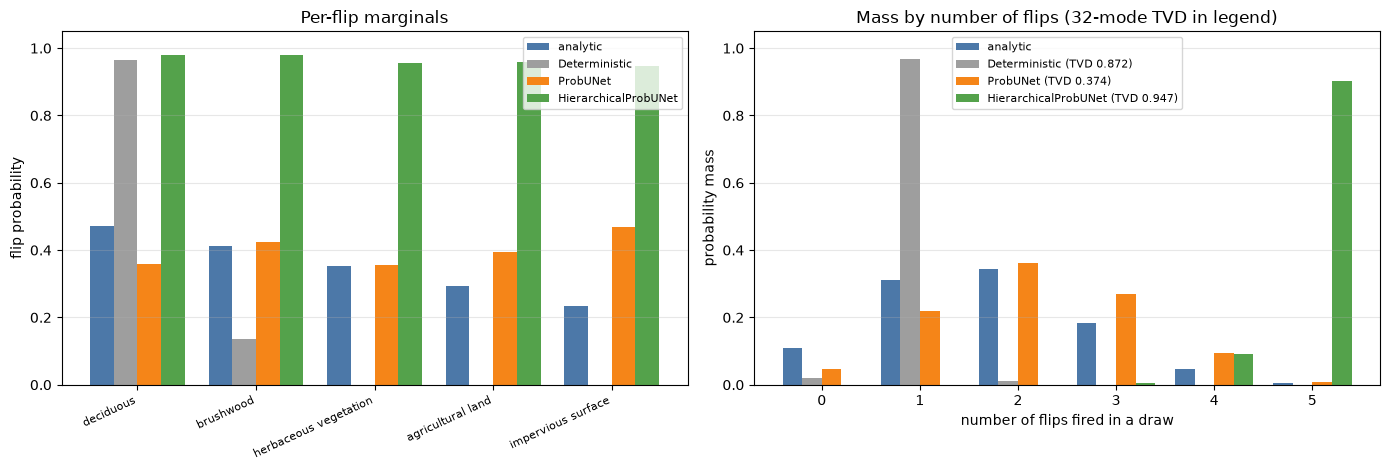

,0 flips,1 flips,2 flips,3 flips,4 flips,5 flips
analytic,0.109,0.311,0.344,0.184,0.048,0.005
Deterministic,0.021,0.969,0.010,0.000,0.000,0.000
ProbUNet,0.047,0.218,0.363,0.270,0.095,0.008
HierarchicalProbUNet,0.000,0.000,0.000,0.004,0.092,0.904


In [19]:
analytic = mode_probabilities()
colors = {
    "Deterministic": "#9E9E9E",
    "ProbUNet": "#F58518",
    "HierarchicalProbUNet": "#54A24B",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
ax = axes[0]
width = 0.2
x = np.arange(len(FLIPS))
ax.bar(
    x - 1.5 * width, [p for _, _, p in FLIPS], width, label="analytic", color="#4C78A8"
)
for k, name in enumerate(MODELS):
    ax.bar(
        x + (k - 0.5) * width,
        calibration[name]["marginals"],
        width,
        label=name,
        color=colors[name],
    )
ax.set_xticks(x)
ax.set_xticklabels(
    [BASE_CLASSES[b] for b, _, _ in FLIPS], rotation=25, ha="right", fontsize=8
)
ax.set_ylabel("flip probability")
ax.set_ylim(0, 1.05)
ax.set_title("Per-flip marginals")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")

# Probability mass by number of flips fired: independent flips give the
# analytic curve, flips drawn together pile mass at 0 or at 5.
mass = {
    "analytic": [
        sum(p for m, p in analytic.items() if sum(m) == k)
        for k in range(len(FLIPS) + 1)
    ]
}
for name in MODELS:
    rec = calibration[name]["recovered"]
    mass[name] = [
        sum(p for m, p in rec.items() if sum(m) == k) for k in range(len(FLIPS) + 1)
    ]
ax = axes[1]
k = np.arange(len(FLIPS) + 1)
ax.bar(k - 1.5 * width, mass["analytic"], width, label="analytic", color="#4C78A8")
for j, name in enumerate(MODELS):
    ax.bar(
        k + (j - 0.5) * width,
        mass[name],
        width,
        color=colors[name],
        label=f"{name} (TVD {calibration[name]['TVD']:.3f})",
    )
ax.set_xticks(k)
ax.set_xlabel("number of flips fired in a draw")
ax.set_ylabel("probability mass")
ax.set_ylim(0, 1.05)
ax.set_title("Mass by number of flips (32-mode TVD in legend)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()
plt.close(fig)

pd.DataFrame(mass, index=[f"{k} flips" for k in range(len(FLIPS) + 1)]).T.round(3)

*Results pending.*